In [180]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [181]:
data = pd.read_excel('0050_歷史股價與成交量.xlsx')

data = data[data["成交量"] > 0].copy()


In [182]:
for numbers in [1,2,3,5,10,20]:
    data[f"trade_before{numbers}"] = data["成交量"].shift(numbers)

data["trade_fivemean"] = data["成交量"].rolling(5).mean()

data["trade_tenmean"] = data["成交量"].rolling(10).mean()

data["price_tenmean"] = data["開盤價"].rolling(10).mean()

data["highprice_tenmean"] = data["最高價"].rolling(10).mean()

data["lowprice_tenmean"] = data["最低價"].rolling(10).mean()

data["trade_5std"] = data["成交量"].rolling(5).std()

data["tradechangerate"] = data["成交量"].pct_change()

data["pricechange"] = data["開盤價"].pct_change()

data["highpricechange"] = data["最高價"].pct_change()

data["lowpricechange"] = data["最低價"].pct_change()

data["trade_10dayago_ratio"] = data["成交量"] / data["trade_tenmean"]

data["trade_log"] = np.log1p(data["成交量"])

data["closeprize_1"] = data["收盤價"].shift(1)

data = data.dropna().reset_index(drop = True)


data.head()





,日期,調整後收盤價,收盤價,最高價,最低價,開盤價,成交量,trade_before1,trade_before2,trade_before3,...,highprice_tenmean,lowprice_tenmean,trade_5std,tradechangerate,pricechange,highpricechange,lowpricechange,trade_10dayago_ratio,trade_log,closeprize_1
0,2024-01-31,32.275009,33.587502,33.825001,33.587502,33.812500,27139568,38244096.0,106544936.0,63300248.0,...,33.622500,33.400001,3.667027e+07,-0.290359,-0.008068,-0.009879,-0.012495,0.446311,17.116503,34.037498
1,2024-02-01,32.275009,33.587502,33.625000,33.400002,33.587502,33583900,27139568.0,38244096.0,106544936.0,...,33.771250,33.542501,3.253357e+07,0.237452,-0.006654,-0.005913,-0.005582,0.547592,17.329557,33.587502
2,2024-02-02,32.455185,33.775002,33.799999,33.662498,33.750000,35616952,33583900.0,27139568.0,38244096.0,...,33.823750,33.631250,3.285861e+07,0.060537,0.004838,0.005204,0.007859,0.653800,17.388332,33.587502
3,2024-02-05,32.659378,33.987499,34.049999,33.750000,33.775002,68850940,35616952.0,33583900.0,27139568.0,...,33.869999,33.672500,1.627012e+07,0.933095,0.000741,0.007396,0.002599,1.225433,18.047454,33.775002
4,2024-02-15,34.196854,35.587502,35.674999,35.349998,35.549999,166902248,68850940.0,35616952.0,33583900.0,...,34.081249,33.870000,5.846491e+07,1.424110,0.052554,0.047724,0.047407,2.380433,18.932919,33.987499


In [183]:
features = [
    "trade_before1","trade_before2","trade_before3",
    "trade_before5","trade_before10","trade_before20",
    "成交量","trade_fivemean","trade_tenmean","trade_5std",
    "tradechangerate","trade_10dayago_ratio","trade_log","closeprize_1",
    "開盤價","最高價","最低價","pricechange","highpricechange","lowpricechange",
    "price_tenmean","highprice_tenmean","lowprice_tenmean"
]

X = data[features]
y = data["收盤價"]

splt_idx = int(len(data)*0.8)

X_train = X.iloc[:splt_idx]
X_valid = X.iloc[splt_idx:]

y_train = y.iloc[:splt_idx]
y_valid = y.iloc[splt_idx:]


In [184]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

model_1 = Ridge(alpha=0.7, random_state = 0)
model_1.fit(X_train,y_train)

predict = model_1.predict(X_valid)

mae_1 = mean_absolute_error(y_valid, predict)

rmse_1 = np.sqrt(mean_squared_error(y_valid, predict))




/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.73108e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [185]:
model_2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=5,
    random_state=0,
)

model_2.fit(X_train, y_train)

predict_2 = model_2.predict(X_valid)

mae_2 = mean_absolute_error(y_valid, predict_2)

rmse_2 = np.sqrt(mean_squared_error(y_valid, predict_2))

In [186]:
print(mae_1, rmse_1)

print(mae_2, rmse_2)

0.16385910155304562 0.21054179624067218
9.26928991258137 10.55137133074974


In [187]:
from collections import deque

class TradeVolumePredictor:

    def __init__(self, model, featurecol, init_last20_trade):

        self.model = model

        self.featurecol = featurecol

        self.hist = deque([float(a) for a in init_last20_trade], maxlen=21)

    def build_features(self, srs20: np.ndarray) -> np.ndarray:

        a = srs20[-1]
        prea = srs20[-2]

        feature = {
            "trade_before1": srs20[-2],
            "trade_before2": srs20[-3],
            "trade_before3": srs20[-4],
            "trade_before5": srs20[-6],
            "trade_before10": srs20[-11],
            "trade_before20": srs20[-21],
            "trade_fivemean": srs20[-5:].mean(),
            "trade_tenmean": srs20[-10:].mean(),
            "trade_5std": srs20[-5:].std(ddof=0),
            "trade_log": np.log1p(a),
            "closeprize_1": data["收盤價"].iloc[-2]
        }

        feature["開盤價"]= data["開盤價"].iloc[-1]
        feature["最高價"]= data["最高價"].iloc[-1]
        feature["最低價"]= data["最低價"].iloc[-1]
        feature["price_tenmean"]= data["price_tenmean"].iloc[-1]
        feature["highprice_tenmean"]= data["highprice_tenmean"].iloc[-1]
        feature["lowprice_tenmean"]= data["lowprice_tenmean"].iloc[-1]
        feature["lowpricechange"]= data["lowpricechange"].iloc[-1]
        feature["pricechange"]= data["pricechange"].iloc[-1]
        feature["highpricechange"]= data["highpricechange"].iloc[-1]
        feature["成交量"] = a
        feature["tradechangerate"] = (a-prea) / prea 
        feature["trade_10dayago_ratio"] = a / feature["trade_tenmean"]
        
        x = np.array([[feature[c] for c in self.featurecol]], dtype=np.float64)

        return x
    
    def predict(self,tradetoday: float) -> float:
        a = float(tradetoday)
        if not np.isfinite(a) or a<0 :
            raise ValueError("輸入必須大於０")
        
        close_1 = float(data["收盤價"].iloc[-2])
        
        self.hist.append(a)

        srs20 = np.array(self.hist, dtype= np.float64)
        x = self.build_features(srs20)

        return float(self.model.predict(x)[0])

    
init_last20 = data["成交量"].iloc[-20:].to_list()

tvp = TradeVolumePredictor(model_1, features, init_last20)


In [188]:
%pip install ipywidgets



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [189]:
import ipywidgets as widgets
from IPython.display import display, clear_output

trade_box = widgets.IntText(description="成交量")
btn = widgets.Button(description="Predict")
out = widgets.Output()

def on_click(_):
    with out:
        clear_output()
        pred = tvp.predict(trade_box.value)   
        print(f"預測收盤價：{pred:.2f}")

btn.on_click(on_click)
display(trade_box, btn, out)


IntText(value=0, description='成交量')

Button(description='Predict', style=ButtonStyle())

Output()

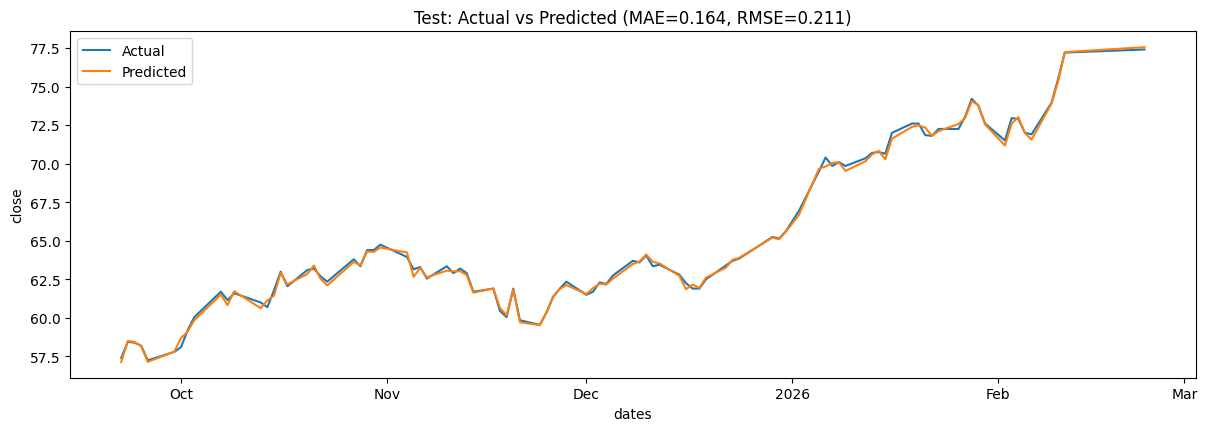

datetime64[ns]


In [190]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

dates = pd.to_datetime(data["日期"].iloc[splt_idx:]).to_numpy()

fig, ax = plt.subplots(figsize = (12,4))
ax.plot(dates, y_valid, label="Actual")
ax.plot(dates, predict, label="Predicted")

loc = mdates.AutoDateLocator(maxticks=20, minticks=5)

ax.xaxis.set_major_locator(loc)

ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

fig.tight_layout()
plt.xlabel("dates")
plt.ylabel("close")
plt.title(f"Test: Actual vs Predicted (MAE={mae_1:.3f}, RMSE={rmse_1:.3f})")
plt.legend()
plt.show()

print(dates.dtype)

/Users/caoxuanyu/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/caoxuanyu/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/caoxuanyu/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/caoxuanyu/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38283 (\N{CJK UNIFIED IDEOGRAPH-958B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/caoxuanyu/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py

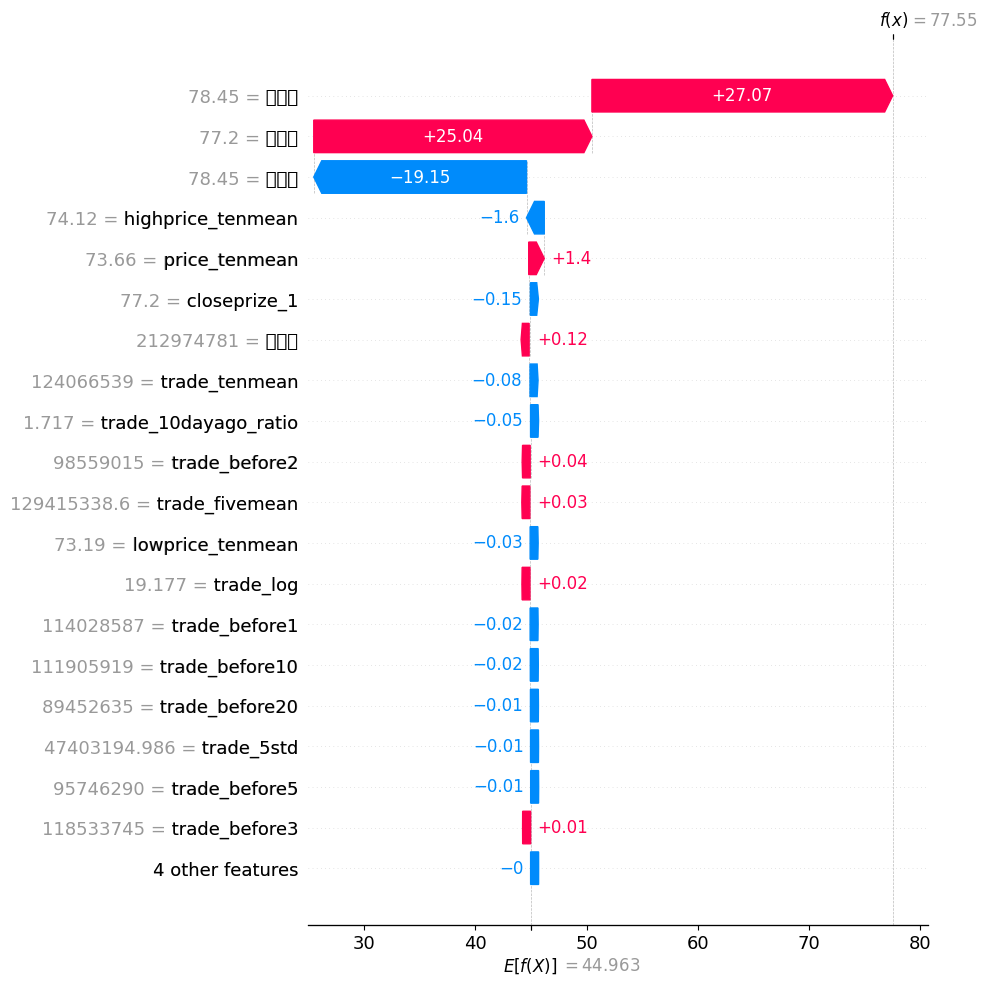

In [191]:
import shap 

data_for_prediction = X_valid.iloc[[-1]] 
explainer = shap.Explainer(model_1, X_train)

shap_values = explainer(data_for_prediction)

shap.initjs()
shap.plots.force(shap_values[0])
shap.plots.waterfall(shap_values[0], max_display=20) 